#1.Template_Matching

Detected 4 logos.


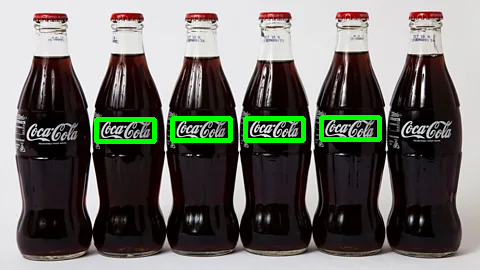

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Load and Check Image
img = cv2.imread("product.jpg")
if img is None:
    print("❌ Error: Image not found.")
else:
    height, width = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Dynamic Coordinate Adjustment
    # We will grab the logo from the center-left bottle.
    # On a standard 1000px wide image, these are the correct proportions:
    y1, y2 = int(height * 0.44), int(height * 0.52)
    x1, x2 = int(width * 0.36), int(width * 0.48)

    template = gray[y1:y2, x1:x2]

    # 3. Enhanced Matching
    # We use TM_CCOEFF_NORMED to handle the reflection on the glass bottles
    res = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF_NORMED)

    # 4. Multi-Object Detection with NMS
    threshold = 0.8 # Start high for precision
    loc = np.where(res >= threshold)

    # Convert to list of points and sort by score
    w, h = template.shape[::-1]
    points = []
    for pt in zip(*loc[::-1]):
        points.append([pt[0], pt[1], res[pt[1], pt[0]]])

    points = sorted(points, key=lambda x: x[2], reverse=True)

    # Simple Non-Maximum Suppression
    final_boxes = []
    min_dist = int(width * 0.1) # Minimum 10% of image width between logos

    for x, y, score in points:
        is_duplicate = False
        for sx, sy in final_boxes:
            if abs(x - sx) < min_dist:
                is_duplicate = True
                break
        if not is_duplicate:
            final_boxes.append((x, y))

    # 5. Visual Feedback
    # Draw the template used so you can see if the "Logo" was picked correctly
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    for (x, y) in final_boxes:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

    print(f"Detected {len(final_boxes)} logos.")
    cv2_imshow(img)

#2.Shape_Matching

✅ Successfully processed 9 potential shapes.


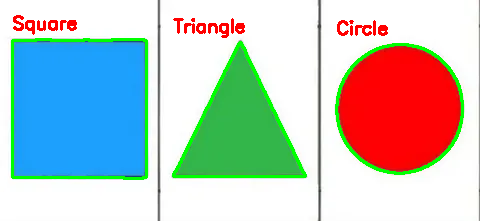

In [11]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import os

# 1. Check if file exists before loading
file_path = "shape.jpg"

if not os.path.exists(file_path):
    print(f"❌ Error: '{file_path}' not found in Colab. Please upload it to the folder icon on the left.")
else:
    image = cv2.imread(file_path)
    # Double check if the image is valid
    if image is None:
        print("❌ Error: Image file is corrupted or not a valid format.")
    else:
        # 2. Pre-processing
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Blur helps remove noise before thresholding
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)

        # 3. Contour Detection
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 500: # Ignore tiny noise particles
                continue

            # Perimeter and Approximation
            peri = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
            vertices = len(approx)

            # Bounding Box for text placement
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h

            # 4. Improved Shape Logic
            if vertices == 3:
                shape = "Triangle"
            elif vertices == 4:
                # Distinguish between Square and Rectangle
                shape = "Square" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"
            elif vertices == 5:
                shape = "Pentagon"
            else:
                shape = "Circle"

            # 5. Drawing Results
            cv2.drawContours(image, [cnt], -1, (0, 255, 0), 2)
            cv2.putText(image, shape, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        print(f"✅ Successfully processed {len(contours)} potential shapes.")
        cv2_imshow(image)


#3.Face_Detection system that:
Detects faces in:
Webcam photo

Starting webcam... please allow camera access when prompted.


<IPython.core.display.Javascript object>

Saved to photo.jpg
Faces detected: 1


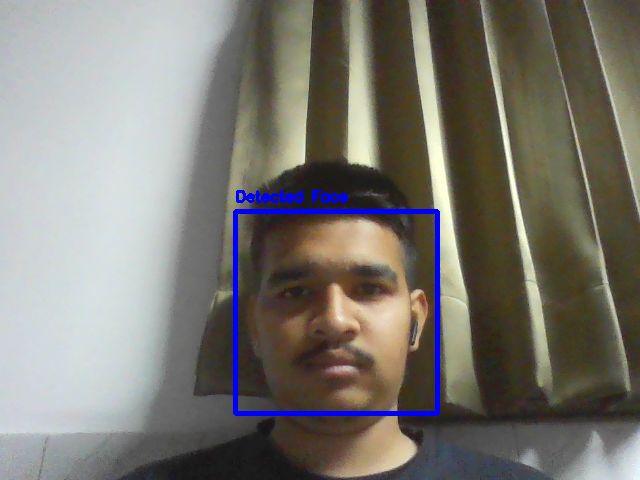

In [15]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# 1. Initialize the Face Detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# 2. JavaScript to Bridge Web Cam to Colab
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Face';
      capture.style.display = 'block';
      capture.style.marginBottom = '10px';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Click
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# 3. Execution Pipeline
try:
  print("Starting webcam... please allow camera access when prompted.")
  filename = take_photo()
  print(f'Saved to {filename}')

  # Read the captured image
  image = cv2.imread(filename)
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Detect Faces
  faces = face_cascade.detectMultiScale(gray, 1.1, 6, minSize=(30, 30))

  # Draw Rectangles
  for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 3)
    cv2.putText(image, "Detected Face", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

  # Display Results
  print(f"Faces detected: {len(faces)}")
  cv2_imshow(image)

except Exception as err:
  # This will trigger if the user denies camera access
  print(f"Error: {str(err)}")

Total Faces Detected: 3


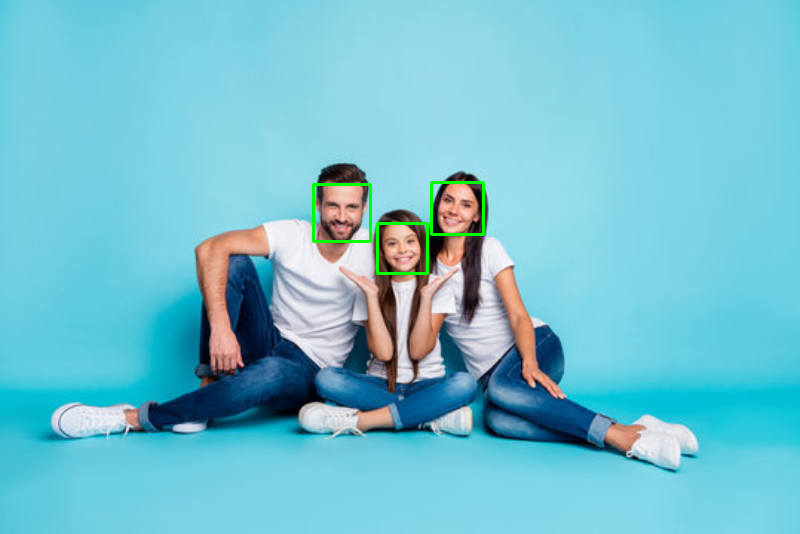

In [20]:
import cv2
import os
from google.colab.patches import cv2_imshow

# Make sure image exists
if not os.path.exists("group2.jpg"):
    print("Upload group.jpg first!")
else:
    # Load image
    image = cv2.imread("group2.jpg")

    # Resize large image (important for detection)
    image = cv2.resize(image, (800, int(image.shape[0] * 800 / image.shape[1])))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Load cascade
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    # Try more sensitive parameters
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(20, 20)
    )

    print("Total Faces Detected:", len(faces))

    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2_imshow(image)